# ABLA — Controlled Ablation of ESN Reservoir Size

This notebook isolates the effect of the **number of reservoir units** on multi-temperature effusivity prediction. It deliberately includes small, moderate, and potentially over-parameterized reservoirs:

\[
R\in\{5,10,20,30,50,75,100\}.
\]

Everything else is fixed:

- absolute smoothed Primary and Secondary sensor values;
- 0–3 s post-contact analysis window;
- five ESN input channels;
- leak rate, spectral radius, input magnitude and washout;
- nine summarized trajectory statistics per reservoir unit;
- the same 27 scalar thermal features;
- the same XGBoost hyperparameters and target transformation; and
- the same 14 leave-one-material-out folds.

The regressor input for reservoir size (R) contains:

\[
9R+27
\]

predictors. At (R=100), this produces 927 predictors despite only 312 trials being available in each outer LOMO training fold. The purpose is to observe the resulting performance and instability rather than assume that larger reservoirs are better.


# 1. Imports and fixed configuration


In [1]:
from pathlib import Path
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor


In [2]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
TARGET = "eff"
ANALYSIS_WINDOW = (0.0, 3.0)

# Edit this tuple to add or remove intentionally extreme reservoir sizes.
RES_SIZE_VALUES = (5, 10, 20, 30, 50, 75, 100)

FIXED_ESN_PARAMS = {
    "leak_rate": 0.30,
    "input_magnitude": 1.00,
    "spectral_radius": 0.90,
    "washout": 0,
}
XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "min_child_weight": 5,
    "reg_alpha": 0.10,
    "reg_lambda": 10.0,
}

# Three reservoirs reduce dependence on a single random reservoir realization.
# For a quick screening run, temporarily use (42,). Restore all three for reporting.
RESERVOIR_SEEDS = (42, 43, 44)
RANDOM_STATE = 42
CLIP_PREDICTIONS_TO_TRAIN_RANGE = True
SUMMARY_NAMES = (
    "mean", "std", "min", "max", "initial",
    "net_change", "slope", "mean_abs", "abs_auc",
)

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "ablation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_STEM = "ABLA_reservoir_size_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO"

print("Reservoir sizes:", RES_SIZE_VALUES)
print("Fixed ESN HPs:", FIXED_ESN_PARAMS)
print("Fixed XGBoost HPs:", XGB_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)


Reservoir sizes: (5, 10, 20, 30, 50, 75, 100)
Fixed ESN HPs: {'leak_rate': 0.3, 'input_magnitude': 1.0, 'spectral_radius': 0.9, 'washout': 0}
Fixed XGBoost HPs: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 10.0}
Reservoir seeds: (42, 43, 44)


## Controlled-ablation interpretation

This is not an Optuna or Bayesian search. Every declared reservoir size is evaluated explicitly under the same settings. The pooled LOMO metrics identify an exploratory best size, while the per-material table reveals whether a larger reservoir improves the pooled score at the cost of unstable unseen-material behavior.

Using the same XGBoost parameters keeps the comparison controlled. It does not guarantee that every reservoir size receives its individually optimal regressor.


# 2. Load trials and assign standard material properties


In [3]:
STANDARD_PROPERTIES = {
    "ps_foam": {"k": .034, "rho": 25., "cp": 1400.},
    "pu_foam": {"k": .043, "rho": 30., "cp": 1400.},
    "cork": {"k": .043, "rho": 240., "cp": 1800.},
    "wood": {"k": .150, "rho": 700., "cp": 1700.},
    "pdms": {"k": .150, "rho": 970., "cp": 1460.},
    "gypsum": {"k": .170, "rho": 800., "cp": 1090.},
    "cement": {"k": .290, "rho": 1440., "cp": 750.},
    "graphite": {"k": 100., "rho": 1820., "cp": 710.},
    "bismuth": {"k": 8.1, "rho": 9780., "cp": 130.},
    "titanium": {"k": 21.9, "rho": 4506., "cp": 523.},
    "nickel": {"k": 90.9, "rho": 8908., "cp": 461.},
    "iron": {"k": 80.4, "rho": 7874., "cp": 449.},
    "aluminum": {"k": 237., "rho": 2700., "cp": 897.},
    "copper": {"k": 401., "rho": 8960., "cp": 385.},
}
ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum", "cement": "cement",
    "graphite": "graphite", "carbon": "graphite", "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium", "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron", "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
for temperature in TEMPERATURE_FOLDERS:
    for path in sorted((DATA_ROOT / temperature).glob("*.csv")):
        frame = pd.read_csv(path)
        if required - set(frame.columns):
            continue
        frame["Temperature"] = temperature
        frame["Temperature_C"] = float(temperature.rstrip("C"))
        frames.append(frame)
if not frames:
    raise ValueError("No valid preprocessed trial files were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary", "Temperature_C"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature", "Temperature_C"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
normalized = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
DATA["Sample"] = normalized.map(ALIASES)
if DATA["Sample"].isna().any():
    raise KeyError("At least one material name does not have a recognized alias.")
for name in ("k", "rho", "cp"):
    DATA[name] = DATA["Sample"].map(lambda material: STANDARD_PROPERTIES[material][name])
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA["trial_id"] = (
    DATA["Temperature"] + "__" + DATA["Sample"] + "_trial_" + DATA["Trial"].astype(str)
)
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)
print("Raw trial count:", DATA["trial_id"].nunique())


Raw trial count: 336


# 3. Contact alignment and fixed 0–3 s window


In [4]:
def find_contact_time(trial, smooth_window=15, polyorder=2, threshold_frac=.30, skip_samples=5):
    clean = (
        trial[["Time", "Primary"]].dropna().sort_values("Time")
        .drop_duplicates("Time").reset_index(drop=True)
    )
    time_values = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time_values) <= 0):
        raise ValueError("Invalid sequence for contact detection.")
    time_values, signal = time_values[skip_samples:], signal[skip_samples:]
    window = min(smooth_window, len(signal))
    if window % 2 == 0:
        window -= 1
    smooth = savgol_filter(signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, time_values)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(time_values[elbow])


aligned_trials = {}
metadata_rows = []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue
    trial["time_from_contact"] = trial["Time"] - contact
    trial = trial[trial["time_from_contact"].between(*ANALYSIS_WINDOW)].copy()
    if len(trial) < 8:
        warnings.warn(f"Skipping {trial_id}: too few samples in 0–3 s.")
        continue
    trial = trial.reset_index(drop=True)
    aligned_trials[trial_id] = trial
    metadata_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })

METADATA = pd.DataFrame(metadata_rows).sort_values("trial_id").reset_index(drop=True)
if METADATA["Sample"].nunique() != 14:
    warnings.warn(f"Expected 14 materials but retained {METADATA['Sample'].nunique()}.")
print("Aligned trials retained:", len(METADATA))
print("Materials retained:", METADATA["Sample"].nunique())


Aligned trials retained: 336
Materials retained: 14


# 4. Absolute-smoothed ESN inputs and variable-size reservoir

The five channels supplied directly to the ESN are smoothed Primary, smoothed Secondary, their difference, and their two time derivatives. There is no baseline centering, min–max normalization or StandardScaler.


In [5]:
def smooth_signal(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= 5 else values.copy()
    )


def esn_input(trial):
    time_values = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    return np.column_stack([
        primary,
        secondary,
        primary - secondary,
        np.gradient(primary, time_values),
        np.gradient(secondary, time_values),
    ])


class ManualReservoir:
    def __init__(self, res_size, random_state):
        self.res_size = int(res_size)
        self.leak_rate = float(FIXED_ESN_PARAMS["leak_rate"])
        self.washout = int(FIXED_ESN_PARAMS["washout"])
        rng = np.random.default_rng(random_state)
        self.Win = (
            rng.random((self.res_size, 1 + 5)) - 0.5
        ) * FIXED_ESN_PARAMS["input_magnitude"]
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * FIXED_ESN_PARAMS["spectral_radius"]

    def run(self, sequence):
        x = np.zeros((self.res_size, 1))
        states = []
        for row in np.asarray(sequence, float):
            proposed = np.tanh(
                self.Win @ np.r_[1.0, row].reshape(-1, 1) + self.W @ x
            )
            x = (1 - self.leak_rate) * x + self.leak_rate * proposed
            states.append(x[:, 0].copy())
        states = np.asarray(states)
        if len(states) <= self.washout:
            raise ValueError("The reservoir sequence is shorter than the washout.")
        return states[self.washout:]


def summarize_states(time_values, states):
    time_values = np.asarray(time_values, float)
    states = np.asarray(states, float)
    output = {}
    for unit in range(states.shape[1]):
        x = states[:, unit]
        prefix = f"esn_u{unit:03d}"
        output.update({
            f"{prefix}_mean": float(np.mean(x)),
            f"{prefix}_std": float(np.std(x)),
            f"{prefix}_min": float(np.min(x)),
            f"{prefix}_max": float(np.max(x)),
            f"{prefix}_initial": float(x[0]),
            f"{prefix}_net_change": float(x[-1] - x[0]),
            f"{prefix}_slope": float(np.polyfit(time_values, x, 1)[0]),
            f"{prefix}_mean_abs": float(np.mean(np.abs(x))),
            f"{prefix}_abs_auc": float(np.trapezoid(np.abs(x), time_values)),
        })
    return output


# 5. Scalar thermal features over the same 0–3 s interval


In [6]:
THERMAL_SLOPE_WINDOWS = {
    "early": (0.0, 1.0),
    "middle": (1.0, 2.0),
    "late": (2.0, 3.0),
}


def signal_slope(time_values, values, window):
    mask = (time_values >= window[0]) & (time_values <= window[1])
    if mask.sum() < 3:
        return np.nan
    return float(np.polyfit(time_values[mask], values[mask], 1)[0])


def extract_thermal_features(trial):
    time_values = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    difference = primary - secondary
    result = {}
    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time_values)
        result[f"thermal_{name}_final_change"] = float(change[-1])
        result[f"thermal_{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"thermal_{name}_response_auc"] = float(np.trapezoid(np.abs(change), time_values))
        result[f"thermal_{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"thermal_{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time_values))
        for window_name, window in THERMAL_SLOPE_WINDOWS.items():
            result[f"thermal_{name}_{window_name}_slope"] = signal_slope(
                time_values, signal, window
            )

    primary_auc = result["thermal_primary_response_auc"]
    result["thermal_secondary_primary_auc_ratio"] = (
        result["thermal_secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["thermal_initial_sensor_difference"] = float(difference[0])
    result["thermal_final_sensor_difference"] = float(difference[-1])
    return result


THERMAL_FEATURES = pd.DataFrame([
    {"trial_id": trial_id, **extract_thermal_features(trial)}
    for trial_id, trial in aligned_trials.items()
]).set_index("trial_id").sort_index()
print("Scalar thermal predictors:", THERMAL_FEATURES.shape[1])
display(THERMAL_FEATURES.head())


Scalar thermal predictors: 27


,thermal_primary_final_change,thermal_primary_max_abs_change,thermal_primary_response_auc,thermal_primary_max_abs_rate,thermal_primary_rate_auc,thermal_primary_early_slope,thermal_primary_middle_slope,thermal_primary_late_slope,thermal_secondary_final_change,thermal_secondary_max_abs_change,...,thermal_difference_max_abs_change,thermal_difference_response_auc,thermal_difference_max_abs_rate,thermal_difference_rate_auc,thermal_difference_early_slope,thermal_difference_middle_slope,thermal_difference_late_slope,thermal_secondary_primary_auc_ratio,thermal_initial_sensor_difference,thermal_final_sensor_difference
trial_id,,,,,,,,,,,,,,,,,,,,,
30C__aluminum_trial_1,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.608193e-07,-2.301865e-07,-7.393007e-07,7.393007e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.999514e-07,1.968456e-07,0.108039,-0.000040,-0.000043
30C__aluminum_trial_2,-0.000003,0.000003,0.000007,0.000004,0.000003,-0.000002,-5.356806e-07,-2.233930e-07,-7.777622e-07,7.777622e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.770283e-07,1.954258e-07,0.126702,-0.000040,-0.000043
30C__aluminum_trial_3,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-4.910211e-07,-2.395687e-07,-8.261538e-07,8.261538e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.242352e-07,1.772203e-07,0.137653,-0.000040,-0.000043
30C__aluminum_trial_4,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.429477e-07,-2.277291e-07,-7.784615e-07,7.784615e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-3.218157e-07,1.910936e-07,0.130203,-0.000040,-0.000043
30C__aluminum_trial_5,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.403697e-07,-2.391434e-07,-8.559441e-07,8.559441e-07,...,0.000002,0.000006,0.000003,0.000003,-0.000002,-3.093597e-07,2.082574e-07,0.151386,-0.000041,-0.000043


# 6. Precompute summarized ESN features for every size and seed

Precomputation is leakage-safe because the absolute-smoothed input transformation does not estimate parameters from other trials. Model fitting remains inside the LOMO loop.


In [7]:
ESN_FEATURES = {}
FEATURE_GENERATION_SECONDS = {}

for res_size in RES_SIZE_VALUES:
    started = time.perf_counter()
    for seed in RESERVOIR_SEEDS:
        print(f"Generating summarized ESN features: R={res_size}, seed={seed}")
        reservoir = ManualReservoir(res_size=res_size, random_state=seed)
        rows = []
        for trial_id in METADATA["trial_id"]:
            trial = aligned_trials[trial_id]
            time_values = trial["time_from_contact"].to_numpy(float)
            states = reservoir.run(esn_input(trial))
            state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
            rows.append({
                "trial_id": trial_id,
                **summarize_states(state_time, states),
            })
        esn_table = pd.DataFrame(rows).set_index("trial_id").sort_index()
        ESN_FEATURES[(res_size, seed)] = esn_table.join(
            THERMAL_FEATURES, how="left", validate="one_to_one"
        )
    FEATURE_GENERATION_SECONDS[res_size] = time.perf_counter() - started

FEATURE_COUNTS = pd.DataFrame([
    {
        "res_size": res_size,
        "esn_predictors": len(SUMMARY_NAMES) * res_size,
        "thermal_predictors": THERMAL_FEATURES.shape[1],
        "total_predictors": len(SUMMARY_NAMES) * res_size + THERMAL_FEATURES.shape[1],
        "outer_training_trials": len(METADATA) - int((METADATA["Sample"] == METADATA["Sample"].iloc[0]).sum()),
        "predictor_to_training_trial_ratio": (
            (len(SUMMARY_NAMES) * res_size + THERMAL_FEATURES.shape[1])
            / (len(METADATA) - int((METADATA["Sample"] == METADATA["Sample"].iloc[0]).sum()))
        ),
        "feature_generation_seconds": FEATURE_GENERATION_SECONDS[res_size],
    }
    for res_size in RES_SIZE_VALUES
])
display(FEATURE_COUNTS)


Generating summarized ESN features: R=5, seed=42
Generating summarized ESN features: R=5, seed=43
Generating summarized ESN features: R=5, seed=44
Generating summarized ESN features: R=10, seed=42
Generating summarized ESN features: R=10, seed=43
Generating summarized ESN features: R=10, seed=44
Generating summarized ESN features: R=20, seed=42
Generating summarized ESN features: R=20, seed=43
Generating summarized ESN features: R=20, seed=44
Generating summarized ESN features: R=30, seed=42
Generating summarized ESN features: R=30, seed=43
Generating summarized ESN features: R=30, seed=44
Generating summarized ESN features: R=50, seed=42
Generating summarized ESN features: R=50, seed=43
Generating summarized ESN features: R=50, seed=44
Generating summarized ESN features: R=75, seed=42
Generating summarized ESN features: R=75, seed=43
Generating summarized ESN features: R=75, seed=44
Generating summarized ESN features: R=100, seed=42
Generating summarized ESN features: R=100, seed=43
G

,res_size,esn_predictors,thermal_predictors,total_predictors,outer_training_trials,predictor_to_training_trial_ratio,feature_generation_seconds
0,5,45,27,72,312,0.230769,0.947990
1,10,90,27,117,312,0.375000,0.976783
2,20,180,27,207,312,0.663462,1.415370
3,30,270,27,297,312,0.951923,1.529612
4,50,450,27,477,312,1.528846,2.313773
5,75,675,27,702,312,2.250000,2.969764
6,100,900,27,927,312,2.971154,3.873759


# 7. Leakage-safe LOMO evaluation at every reservoir size


In [8]:
def make_regressor(seed):
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=int(seed),
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        **XGB_PARAMS,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    target_range = float(np.ptp(y_true))
    return {
        "n": len(y_true),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range if target_range > 0 else np.nan,
        "r2": float(r2_score(y_true, y_pred)) if target_range > 0 else np.nan,
        "median_ape_pct": float(np.median(np.abs((y_true - y_pred) / y_true)) * 100),
    }


logo = LeaveOneGroupOut()
prediction_rows, fold_rows, evaluation_seconds = [], [], {}

for res_size in RES_SIZE_VALUES:
    started = time.perf_counter()
    print(f"\nEvaluating reservoir size {res_size}")
    for fold, (train_idx, test_idx) in enumerate(
        logo.split(METADATA, groups=METADATA["Sample"]), start=1
    ):
        train_meta = METADATA.iloc[train_idx].reset_index(drop=True)
        test_meta = METADATA.iloc[test_idx].reset_index(drop=True)
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()
        y_train = train_meta[TARGET].to_numpy(float)
        y_test = test_meta[TARGET].to_numpy(float)
        held_out = str(test_meta["Sample"].iloc[0])

        seed_predictions = []
        for seed in RESERVOIR_SEEDS:
            features = ESN_FEATURES[(res_size, seed)]
            X_train = features.loc[train_ids].reset_index(drop=True)
            X_test = features.loc[test_ids].reset_index(drop=True)
            model = make_regressor(seed)
            model.fit(X_train, y_train)
            prediction = model.predict(X_test)
            if CLIP_PREDICTIONS_TO_TRAIN_RANGE:
                prediction = np.clip(prediction, y_train.min(), y_train.max())
            seed_predictions.append(prediction)

        prediction = np.mean(seed_predictions, axis=0)
        residual = prediction - y_test
        rmse = float(np.sqrt(np.mean(residual ** 2)))
        fold_rows.append({
            "res_size": res_size,
            "fold": fold,
            "held_out_material": held_out,
            "n": len(y_test),
            "mae": float(np.mean(np.abs(residual))),
            "rmse": rmse,
            "nrmse_training_range": rmse / float(np.ptp(y_train)),
            "mean_error_bias": float(np.mean(residual)),
            "median_ape_pct": float(np.median(np.abs(residual / y_test)) * 100),
        })
        for row_index, (_, meta_row) in enumerate(test_meta.iterrows()):
            prediction_rows.append({
                "res_size": res_size,
                "fold": fold,
                "trial_id": meta_row["trial_id"],
                "Temperature": meta_row["Temperature"],
                "Temperature_C": meta_row["Temperature_C"],
                "Sample": meta_row["Sample"],
                "Trial": meta_row["Trial"],
                "y_true": y_test[row_index],
                "y_pred": prediction[row_index],
            })
    evaluation_seconds[res_size] = time.perf_counter() - started
    print(f"Completed R={res_size} in {evaluation_seconds[res_size]/60:.1f} min")

OOF = pd.DataFrame(prediction_rows)
FOLD_METRICS = pd.DataFrame(fold_rows)
OVERALL = pd.DataFrame([
    {"res_size": int(res_size), **pooled_metrics(part["y_true"], part["y_pred"])}
    for res_size, part in OOF.groupby("res_size", sort=True)
])
OVERALL["fold_nrmse_sd"] = OVERALL["res_size"].map(
    FOLD_METRICS.groupby("res_size")["nrmse_training_range"].std(ddof=1)
)
OVERALL["evaluation_seconds"] = OVERALL["res_size"].map(evaluation_seconds)
OVERALL = OVERALL.merge(FEATURE_COUNTS, on="res_size", how="left", validate="one_to_one")
OVERALL["J_exploratory"] = (
    OVERALL["nrmse_range"]
    + .10 * (1 - OVERALL["r2"])
    + .10 * OVERALL["fold_nrmse_sd"]
)
OVERALL = OVERALL.sort_values("res_size").reset_index(drop=True)
display(OVERALL)

best = OVERALL.loc[OVERALL["J_exploratory"].idxmin()]
print(
    f"Exploratory best size: R={int(best['res_size'])}; "
    f"NRMSE={best['nrmse_range']:.4f}, R²={best['r2']:.4f}, "
    f"J={best['J_exploratory']:.4f}"
)



Evaluating reservoir size 5
Completed R=5 in 0.1 min

Evaluating reservoir size 10
Completed R=10 in 0.2 min

Evaluating reservoir size 20
Completed R=20 in 0.2 min

Evaluating reservoir size 30
Completed R=30 in 0.3 min

Evaluating reservoir size 50
Completed R=50 in 0.4 min

Evaluating reservoir size 75
Completed R=75 in 0.6 min

Evaluating reservoir size 100
Completed R=100 in 0.7 min


,res_size,n,mae,rmse,nrmse_range,r2,median_ape_pct,fold_nrmse_sd,evaluation_seconds,esn_predictors,thermal_predictors,total_predictors,outer_training_trials,predictor_to_training_trial_ratio,feature_generation_seconds,J_exploratory
0,5,336,4638.746223,8225.410108,0.221362,0.461429,54.580720,0.264345,8.737231,45,27,72,312,0.230769,0.947990,0.301654
1,10,336,4678.097652,8291.695481,0.223146,0.452713,53.502497,0.266891,10.031050,90,27,117,312,0.375000,0.976783,0.304564
2,20,336,4520.978480,8116.525269,0.218432,0.475593,51.384683,0.263939,13.468206,180,27,207,312,0.663462,1.415370,0.297267
3,30,336,4698.316434,8396.503901,0.225967,0.438790,53.137198,0.272134,17.067160,270,27,297,312,0.951923,1.529612,0.309301
4,50,336,4768.865425,8407.967394,0.226275,0.437257,54.123913,0.268753,23.987293,450,27,477,312,1.528846,2.313773,0.309425
5,75,336,4762.774620,8338.257954,0.224399,0.446550,54.355303,0.263584,33.751328,675,27,702,312,2.250000,2.969764,0.306103
6,100,336,4777.773076,8361.695193,0.225030,0.443434,55.724666,0.264508,43.288889,900,27,927,312,2.971154,3.873759,0.307138


Exploratory best size: R=20; NRMSE=0.2184, R²=0.4756, J=0.2973


# 8. Performance, stability and dimensionality versus reservoir size


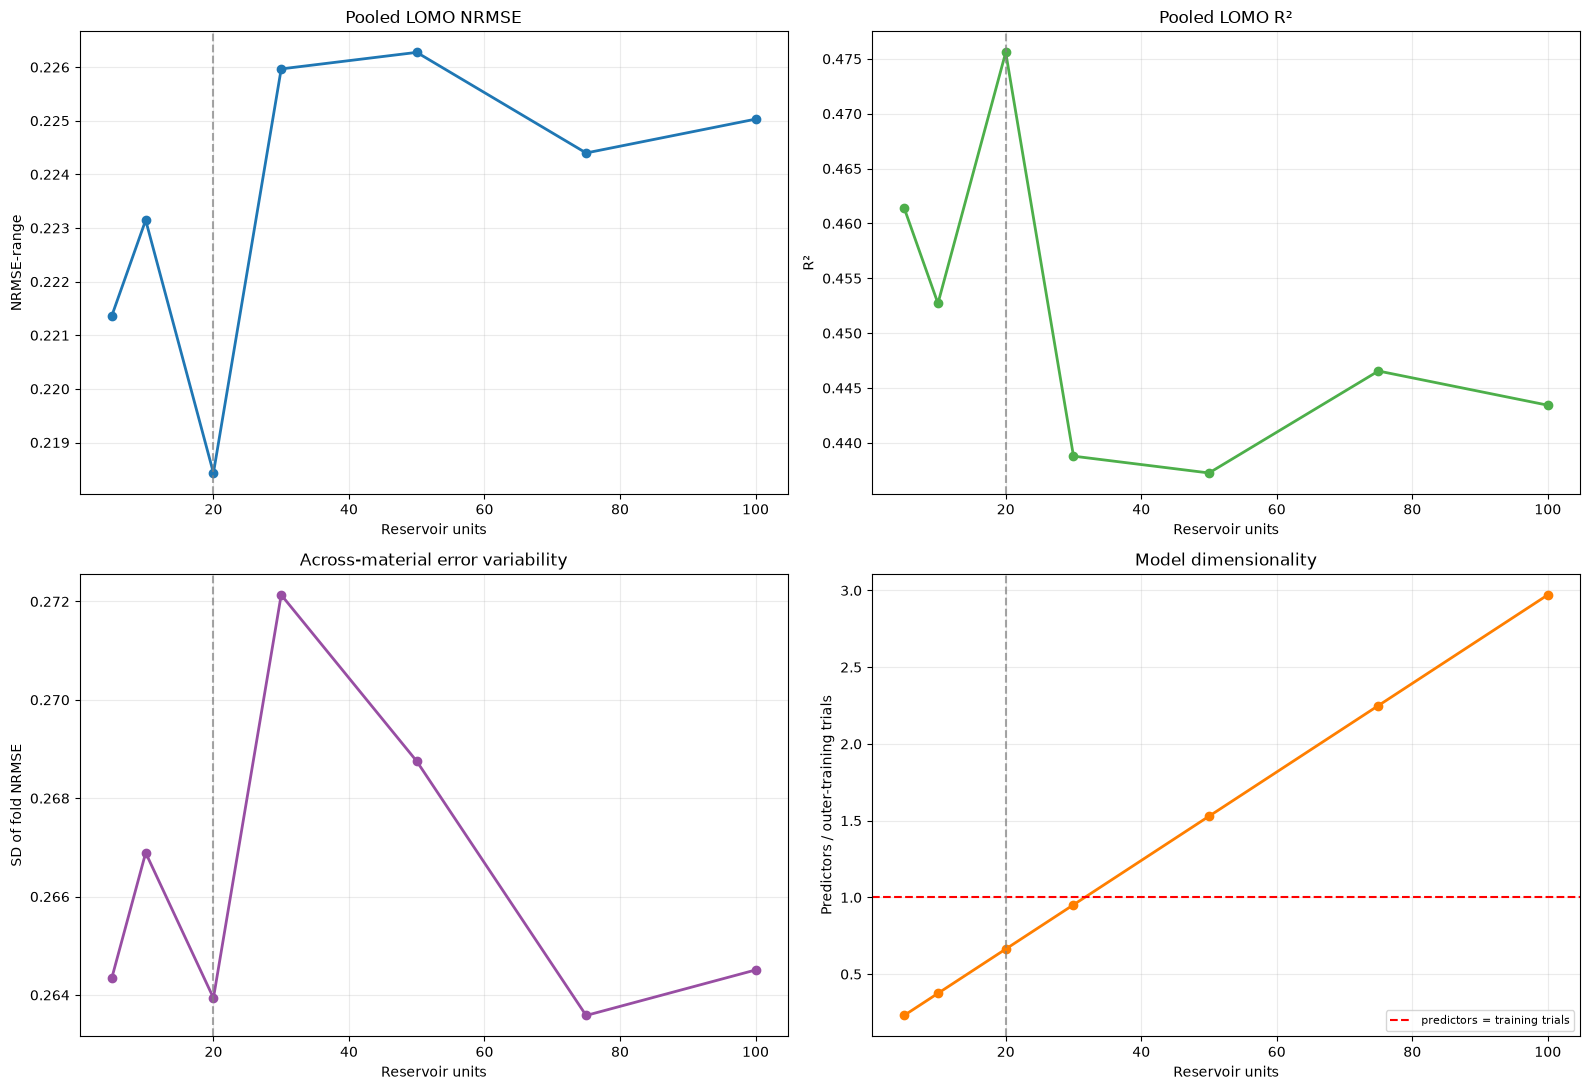

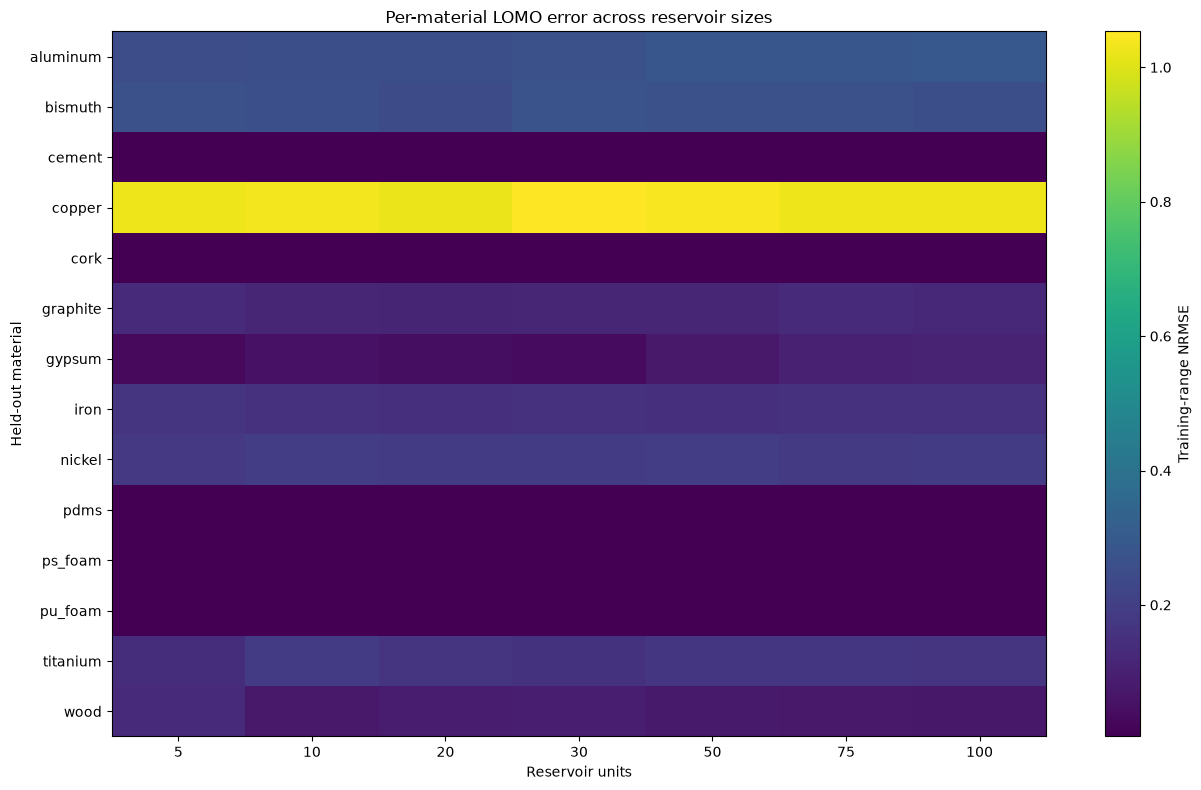

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()
axes[0].plot(OVERALL["res_size"], OVERALL["nrmse_range"], "o-", linewidth=2)
axes[0].set(title="Pooled LOMO NRMSE", ylabel="NRMSE-range")
axes[1].plot(OVERALL["res_size"], OVERALL["r2"], "o-", color="#4daf4a", linewidth=2)
axes[1].set(title="Pooled LOMO R²", ylabel="R²")
axes[2].plot(OVERALL["res_size"], OVERALL["fold_nrmse_sd"], "o-", color="#984ea3", linewidth=2)
axes[2].set(title="Across-material error variability", ylabel="SD of fold NRMSE")
axes[3].plot(
    OVERALL["res_size"], OVERALL["predictor_to_training_trial_ratio"],
    "o-", color="#ff7f00", linewidth=2,
)
axes[3].axhline(1, color="red", linestyle="--", label="predictors = training trials")
axes[3].set(title="Model dimensionality", ylabel="Predictors / outer-training trials")
axes[3].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel("Reservoir units")
    ax.axvline(best["res_size"], color="gray", linestyle="--", alpha=.7)
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

heatmap = FOLD_METRICS.pivot(
    index="held_out_material", columns="res_size", values="nrmse_training_range"
)[list(RES_SIZE_VALUES)]
fig, ax = plt.subplots(figsize=(13, 8))
image = ax.imshow(heatmap, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(heatmap.columns)), heatmap.columns)
ax.set_yticks(range(len(heatmap.index)), heatmap.index)
ax.set_xlabel("Reservoir units")
ax.set_ylabel("Held-out material")
ax.set_title("Per-material LOMO error across reservoir sizes")
fig.colorbar(image, ax=ax, label="Training-range NRMSE")
plt.tight_layout()
plt.show()


# 9. Prediction behavior for customizable case-study materials


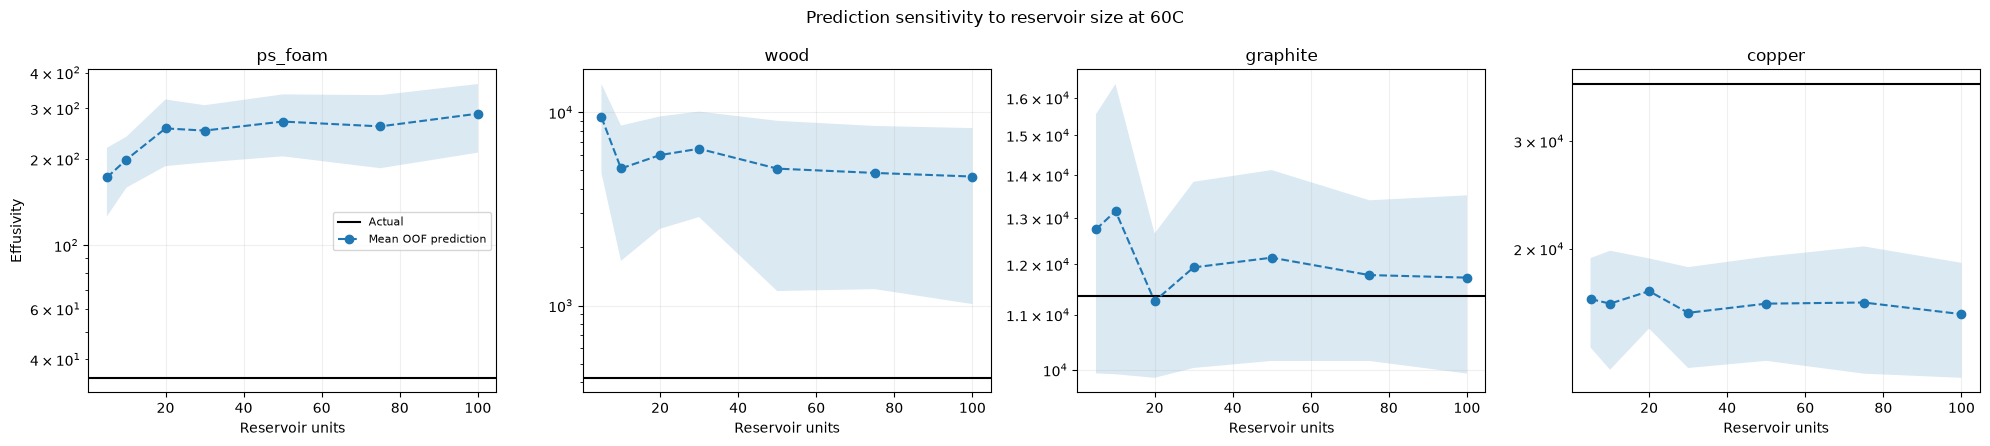

In [10]:
CASE_STUDY_TEMPERATURE = "60C"
CASE_STUDY_MATERIALS = ["ps_foam", "wood", "graphite", "copper"]

case = (
    OOF[
        (OOF["Temperature"] == CASE_STUDY_TEMPERATURE)
        & OOF["Sample"].isin(CASE_STUDY_MATERIALS)
    ]
    .groupby(["res_size", "Sample"], as_index=False)
    .agg(
        y_true=("y_true", "mean"),
        y_pred=("y_pred", "mean"),
        prediction_sd=("y_pred", "std"),
    )
)

fig, axes = plt.subplots(
    1, len(CASE_STUDY_MATERIALS), figsize=(20, 4.5), sharex=True
)
for ax, material in zip(axes, CASE_STUDY_MATERIALS):
    part = case[case["Sample"] == material].sort_values("res_size")
    if part.empty:
        ax.set_visible(False)
        continue
    ax.axhline(part["y_true"].iloc[0], color="black", label="Actual")
    ax.plot(part["res_size"], part["y_pred"], "o--", label="Mean OOF prediction")
    ax.fill_between(
        part["res_size"],
        part["y_pred"] - part["prediction_sd"],
        part["y_pred"] + part["prediction_sd"],
        alpha=.16,
    )
    ax.set_yscale("log")
    ax.set_title(material)
    ax.set_xlabel("Reservoir units")
    ax.grid(alpha=.2)
axes[0].set_ylabel("Effusivity")
axes[0].legend(fontsize=8)
fig.suptitle(f"Prediction sensitivity to reservoir size at {CASE_STUDY_TEMPERATURE}")
plt.tight_layout()
plt.show()


# 10. Collective ESN dynamics across selected reservoir sizes

Individual unit identities are not directly comparable when the reservoir dimension changes. This section therefore compares dimension-independent collective quantities:

- RMS state activation;
- mean absolute activation; and
- fraction of units near tanh saturation, ( |x_j(t)|\geq0.95 ).

These plots help determine whether increasing reservoir size changes the overall dynamic regime, not merely the number of available summaries.


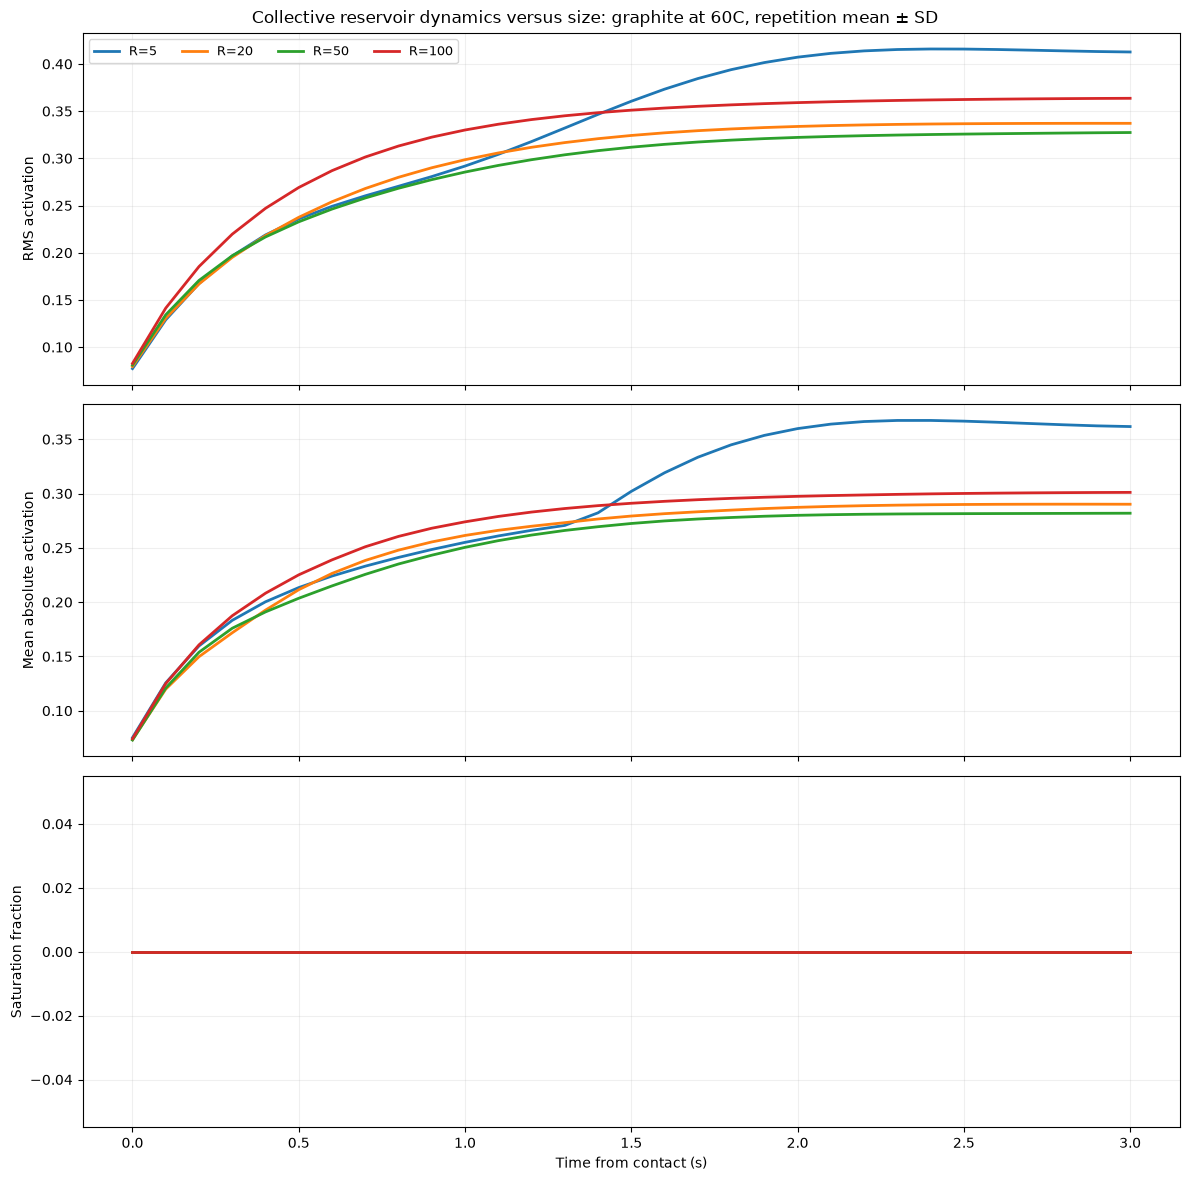

In [11]:
DYNAMICS_MATERIAL = "graphite"
DYNAMICS_TEMPERATURE = "60C"
DYNAMICS_RES_SIZES = (5, 20, 50, 100)
DYNAMICS_SEED = 42

selected = METADATA[
    (METADATA["Sample"] == DYNAMICS_MATERIAL)
    & (METADATA["Temperature"] == DYNAMICS_TEMPERATURE)
].sort_values("Trial")
if selected.empty:
    raise KeyError("Requested dynamics material/temperature was not found.")

common_time = np.linspace(*ANALYSIS_WINDOW, 61)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for res_size in DYNAMICS_RES_SIZES:
    if res_size not in RES_SIZE_VALUES:
        raise KeyError(f"R={res_size} was not declared in RES_SIZE_VALUES.")
    reservoir = ManualReservoir(res_size=res_size, random_state=DYNAMICS_SEED)
    rms_trials, mean_abs_trials, saturation_trials = [], [], []
    for trial_id in selected["trial_id"]:
        trial = aligned_trials[trial_id]
        time_values = trial["time_from_contact"].to_numpy(float)
        states = reservoir.run(esn_input(trial))
        state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
        rms = np.sqrt(np.mean(states ** 2, axis=1))
        mean_abs = np.mean(np.abs(states), axis=1)
        saturation = np.mean(np.abs(states) >= .95, axis=1)
        rms_trials.append(np.interp(common_time, state_time, rms))
        mean_abs_trials.append(np.interp(common_time, state_time, mean_abs))
        saturation_trials.append(np.interp(common_time, state_time, saturation))

    for ax, trials, label in zip(
        axes,
        (rms_trials, mean_abs_trials, saturation_trials),
        ("RMS activation", "Mean absolute activation", "Saturation fraction"),
    ):
        trials = np.asarray(trials)
        mean = trials.mean(axis=0)
        sd = trials.std(axis=0, ddof=1)
        ax.plot(common_time, mean, linewidth=2, label=f"R={res_size}")
        ax.fill_between(common_time, mean - sd, mean + sd, alpha=.10)
        ax.set_ylabel(label)
        ax.grid(alpha=.2)

axes[-1].set_xlabel("Time from contact (s)")
axes[0].legend(ncol=4, fontsize=9)
fig.suptitle(
    f"Collective reservoir dynamics versus size: {DYNAMICS_MATERIAL} at "
    f"{DYNAMICS_TEMPERATURE}, repetition mean ± SD"
)
plt.tight_layout()
plt.show()


# 11. Unit-level trajectories, state heatmaps, and dynamic-complexity diagnostics

This section complements the collective activity curves above. For each selected
reservoir size it shows:

1. every unit's repetition-mean trajectory;
2. a heatmap of repetition-mean activation for all units; and
3. a heatmap of repetition SD for all units.

The accompanying table measures unit redundancy, effective state-space dimension,
activation saturation, temporal variation, and repetition variability. Reservoir
unit indices are **not matched across sizes**: changing `res_size` creates a different
recurrent matrix, even when the same random seed is used.


,res_size,n_repetitions,mean_abs_unit_correlation,effective_rank,effective_rank_fraction,pca_dimensions_95pct,pca95_fraction_of_units,mean_unit_temporal_sd,mean_repetition_sd,saturation_fraction,mean_absolute_activation
0,5,6,0.746445,1.447832,0.289566,2,0.40,0.125055,0.000015,0.0,0.288180
1,20,6,0.690008,1.268008,0.063400,2,0.10,0.073731,0.000005,0.0,0.253802
2,50,6,0.669697,1.598066,0.031961,2,0.04,0.072481,0.000018,0.0,0.246769
3,100,6,0.718144,1.345209,0.022053,2,0.02,0.069818,0.000009,0.0,0.265013


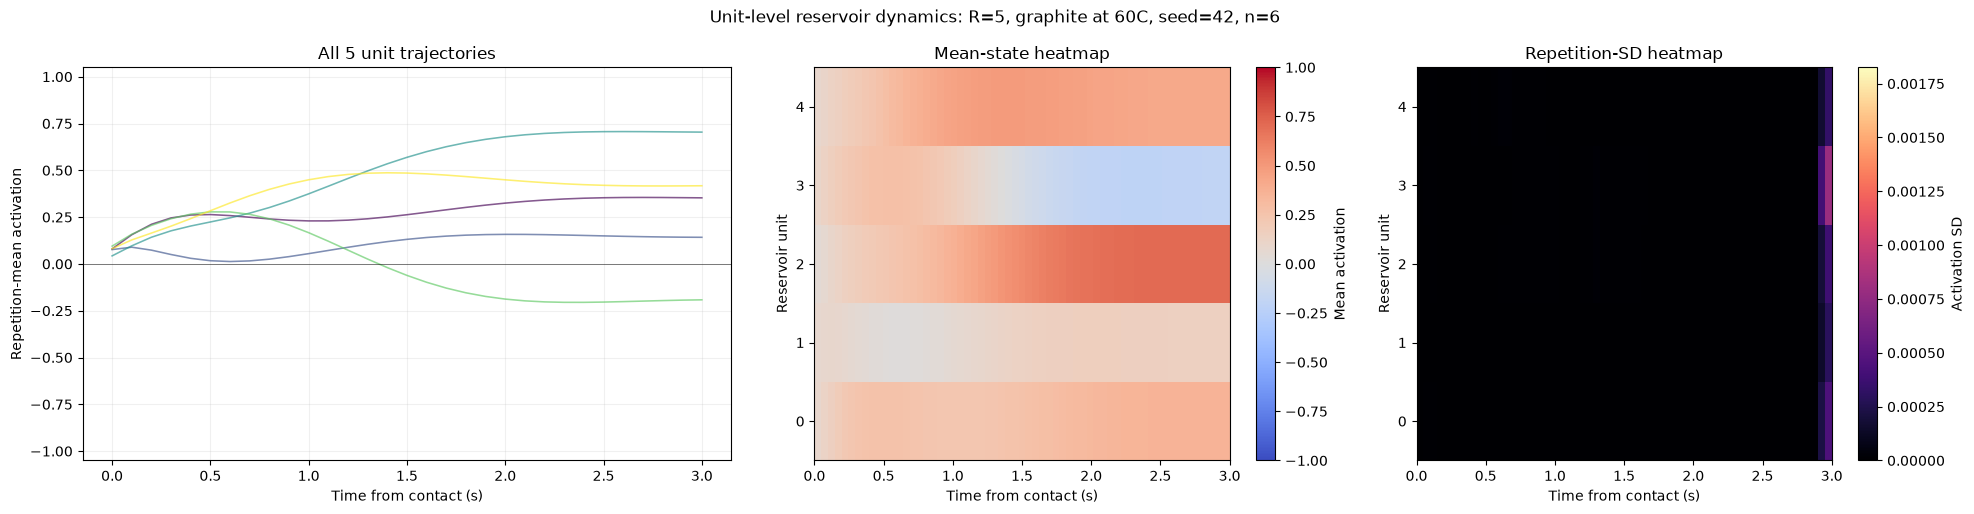

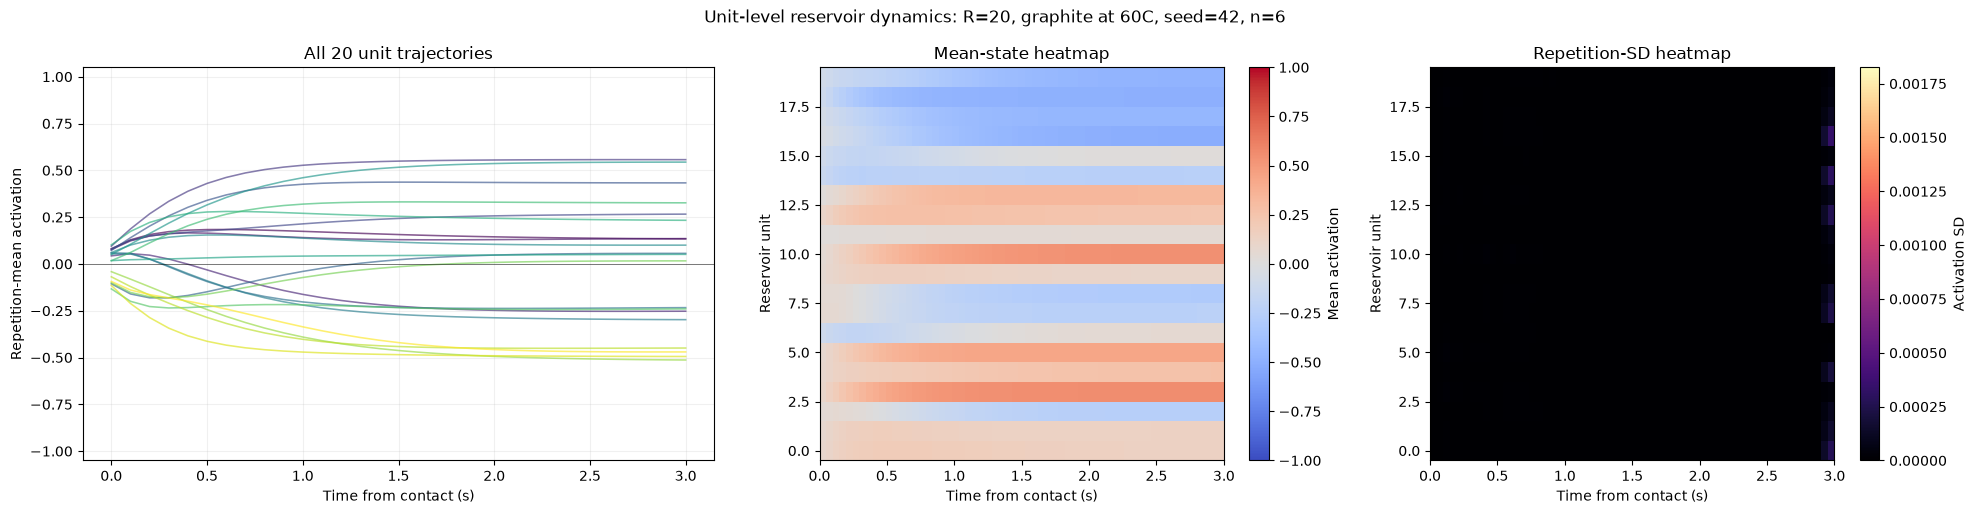

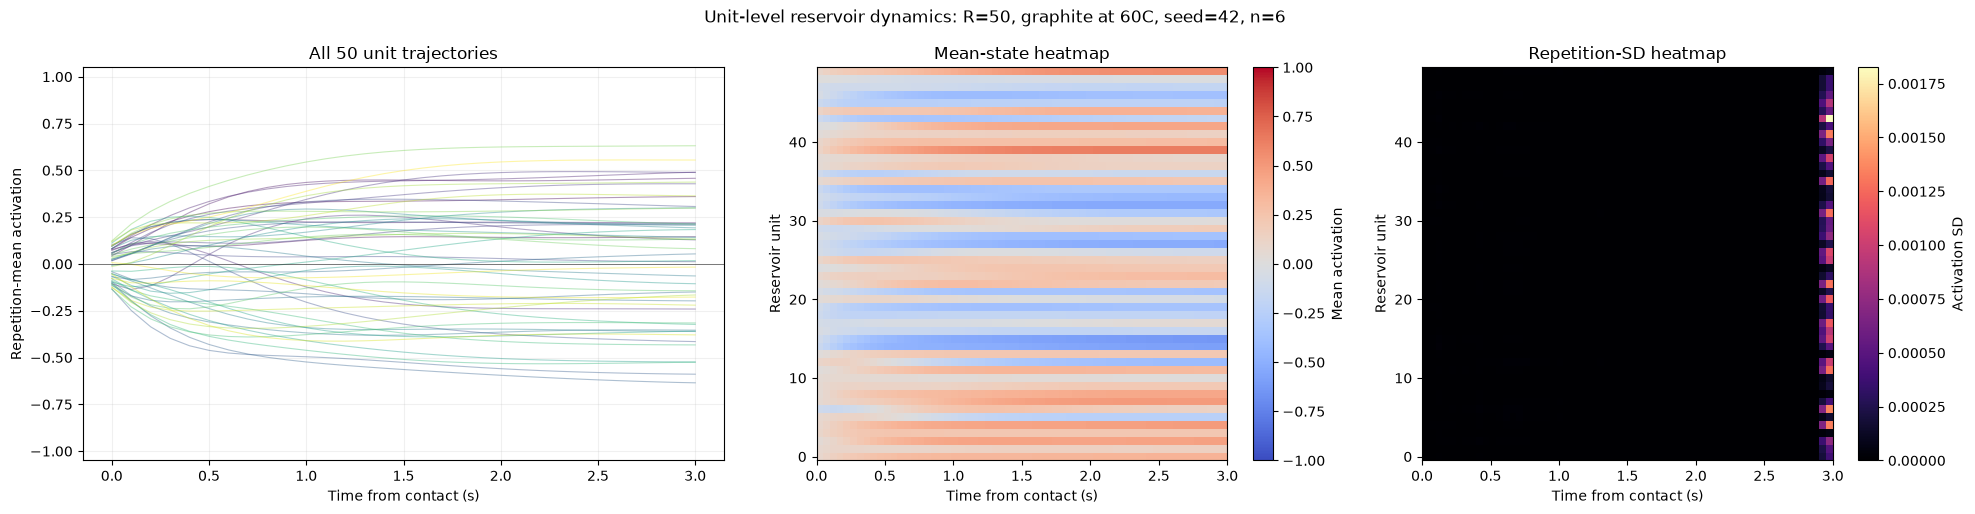

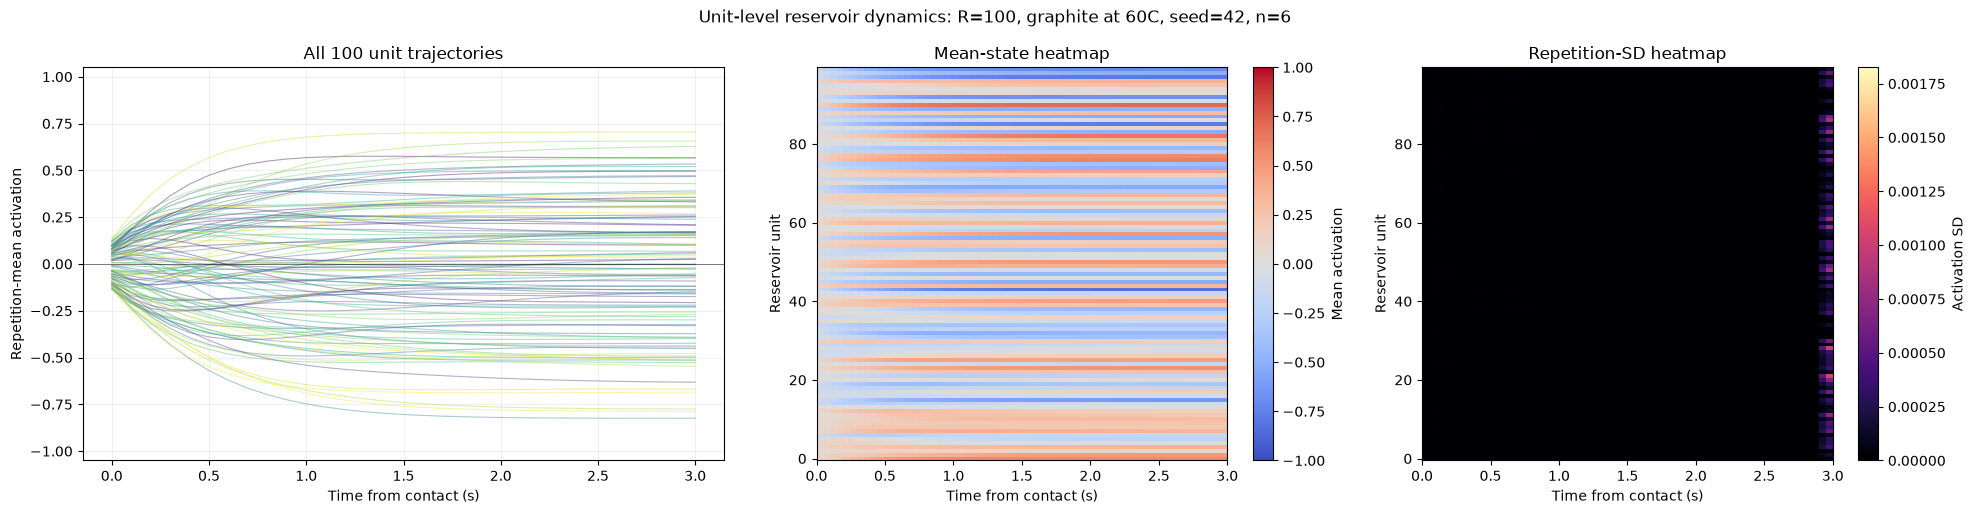

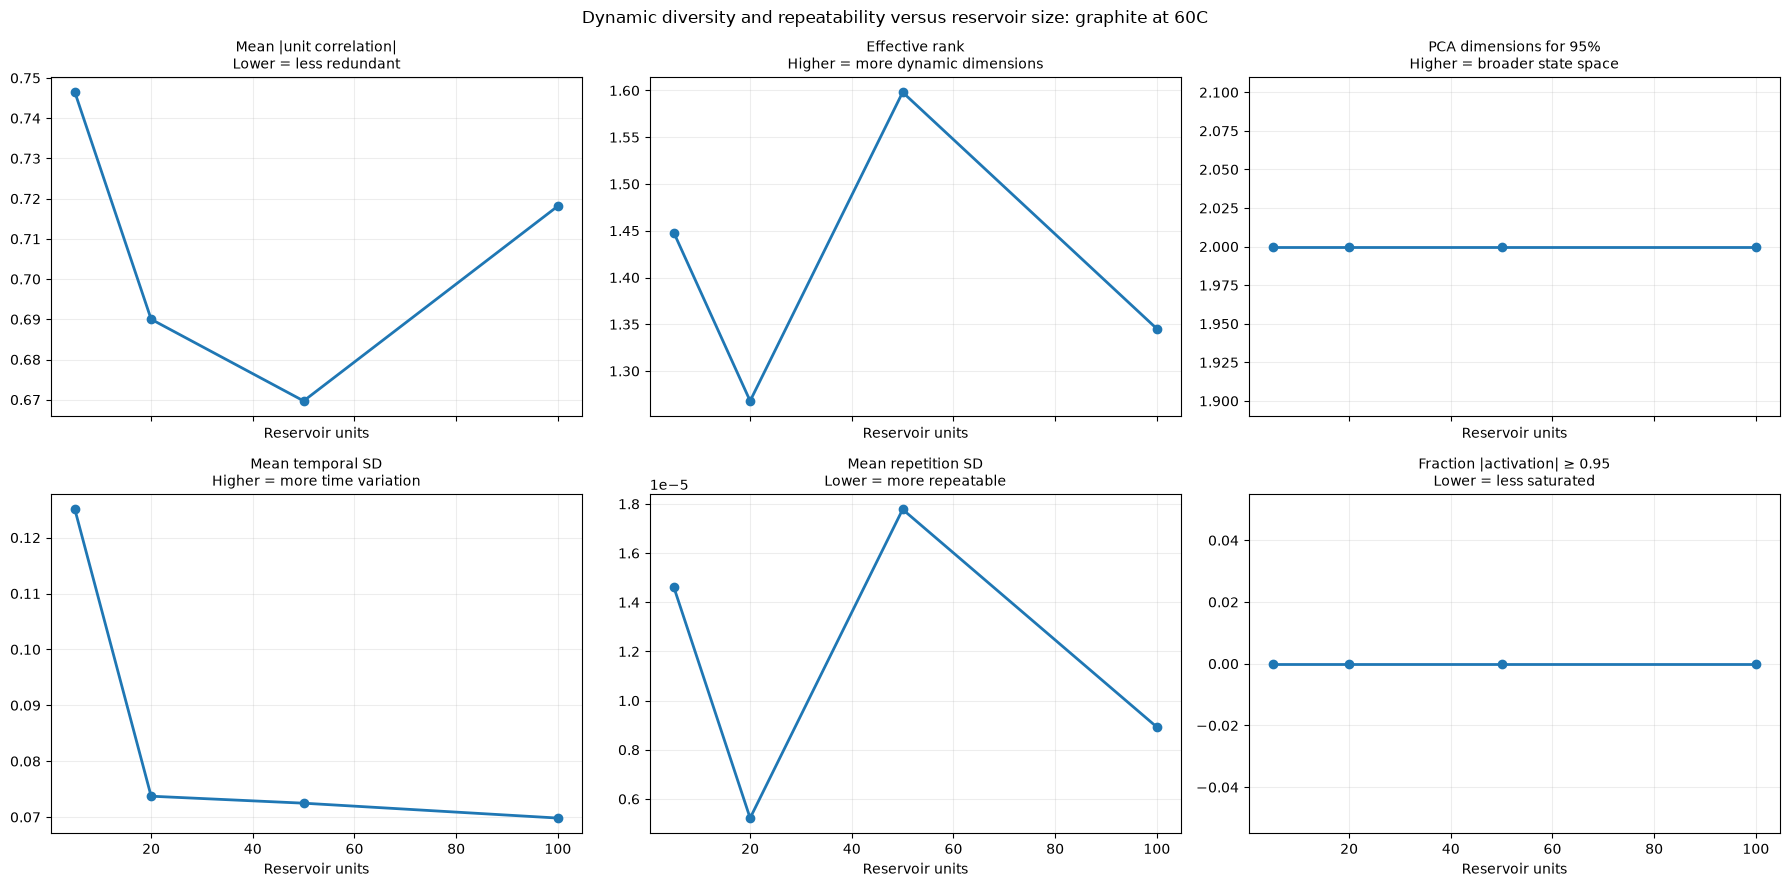

In [12]:
# This section reuses DYNAMICS_MATERIAL, DYNAMICS_TEMPERATURE,
# DYNAMICS_RES_SIZES, DYNAMICS_SEED, and common_time from Section 10.
SATURATION_THRESHOLD = 0.95
PCA_VARIANCE_THRESHOLD = 0.95


def collect_resampled_states(res_size, selected_metadata, seed, target_time):
    """Return repetitions × time × units on a common time axis."""
    reservoir = ManualReservoir(res_size=res_size, random_state=seed)
    repetitions = []
    trial_ids = []
    for trial_id in selected_metadata["trial_id"]:
        trial = aligned_trials[trial_id]
        time_values = trial["time_from_contact"].to_numpy(float)
        states = reservoir.run(esn_input(trial))
        state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
        resampled = np.column_stack([
            np.interp(target_time, state_time, states[:, unit])
            for unit in range(states.shape[1])
        ])
        repetitions.append(resampled)
        trial_ids.append(trial_id)
    return np.asarray(repetitions), trial_ids


def state_complexity_metrics(state_cube, res_size):
    """Summarize diversity, dimensionality, saturation, and repeatability."""
    state_cube = np.asarray(state_cube, float)
    repetition_mean = state_cube.mean(axis=0)  # time × units
    centered = repetition_mean - repetition_mean.mean(axis=0, keepdims=True)

    # Unit-to-unit redundancy is calculated only for units with temporal variance.
    valid = np.std(repetition_mean, axis=0) > 1e-12
    if valid.sum() >= 2:
        correlation = np.corrcoef(repetition_mean[:, valid], rowvar=False)
        off_diagonal = correlation[np.triu_indices_from(correlation, k=1)]
        mean_abs_correlation = float(np.nanmean(np.abs(off_diagonal)))
    else:
        mean_abs_correlation = np.nan

    singular_values = np.linalg.svd(centered, full_matrices=False, compute_uv=False)
    singular_values = singular_values[singular_values > 1e-12]
    if len(singular_values):
        energy = singular_values ** 2
        energy_fraction = energy / energy.sum()
        effective_rank = float(np.exp(-np.sum(energy_fraction * np.log(energy_fraction))))
        pca_dimensions_95 = int(
            np.searchsorted(np.cumsum(energy_fraction), PCA_VARIANCE_THRESHOLD) + 1
        )
    else:
        effective_rank = 0.0
        pca_dimensions_95 = 0

    repetition_sd = state_cube.std(axis=0, ddof=1) if len(state_cube) > 1 else np.zeros_like(repetition_mean)
    temporal_sd_by_unit = repetition_mean.std(axis=0, ddof=0)
    return {
        "res_size": int(res_size),
        "n_repetitions": int(len(state_cube)),
        "mean_abs_unit_correlation": mean_abs_correlation,
        "effective_rank": effective_rank,
        "effective_rank_fraction": effective_rank / min(repetition_mean.shape),
        "pca_dimensions_95pct": pca_dimensions_95,
        "pca95_fraction_of_units": pca_dimensions_95 / res_size,
        "mean_unit_temporal_sd": float(np.mean(temporal_sd_by_unit)),
        "mean_repetition_sd": float(np.mean(repetition_sd)),
        "saturation_fraction": float(
            np.mean(np.abs(state_cube) >= SATURATION_THRESHOLD)
        ),
        "mean_absolute_activation": float(np.mean(np.abs(state_cube))),
    }


UNIT_STATE_CUBES = {}
UNIT_STATE_TRIAL_IDS = {}
DYNAMICS_COMPLEXITY_ROWS = []

for res_size in DYNAMICS_RES_SIZES:
    if res_size not in RES_SIZE_VALUES:
        raise KeyError(f"R={res_size} was not declared in RES_SIZE_VALUES.")
    cube, trial_ids = collect_resampled_states(
        res_size, selected, DYNAMICS_SEED, common_time
    )
    UNIT_STATE_CUBES[res_size] = cube
    UNIT_STATE_TRIAL_IDS[res_size] = trial_ids
    DYNAMICS_COMPLEXITY_ROWS.append(state_complexity_metrics(cube, res_size))

DYNAMICS_COMPLEXITY = pd.DataFrame(DYNAMICS_COMPLEXITY_ROWS)
display(DYNAMICS_COMPLEXITY)

# A common SD color scale permits direct repeatability comparisons across sizes.
all_sd_values = [
    cube.std(axis=0, ddof=1) if len(cube) > 1 else np.zeros_like(cube[0])
    for cube in UNIT_STATE_CUBES.values()
]
sd_color_max = max(float(np.nanmax(values)) for values in all_sd_values)
if not np.isfinite(sd_color_max) or np.isclose(sd_color_max, 0):
    sd_color_max = 1.0

for res_size in DYNAMICS_RES_SIZES:
    cube = UNIT_STATE_CUBES[res_size]
    mean_states = cube.mean(axis=0)  # time × units
    sd_states = cube.std(axis=0, ddof=1) if len(cube) > 1 else np.zeros_like(mean_states)

    fig, axes = plt.subplots(
        1, 3, figsize=(20, 5.2), gridspec_kw={"width_ratios": [1.25, 1, 1]}
    )

    unit_colors = plt.cm.viridis(np.linspace(0, 1, res_size))
    for unit in range(res_size):
        axes[0].plot(
            common_time,
            mean_states[:, unit],
            color=unit_colors[unit],
            linewidth=.8 if res_size >= 50 else 1.15,
            alpha=.40 if res_size >= 50 else .65,
        )
    axes[0].axhline(0, color="black", linewidth=.7, alpha=.5)
    axes[0].set(
        title=f"All {res_size} unit trajectories",
        xlabel="Time from contact (s)",
        ylabel="Repetition-mean activation",
        ylim=(-1.05, 1.05),
    )
    axes[0].grid(alpha=.18)

    mean_image = axes[1].imshow(
        mean_states.T,
        aspect="auto",
        origin="lower",
        extent=[common_time[0], common_time[-1], -.5, res_size - .5],
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        interpolation="nearest",
    )
    axes[1].set(
        title="Mean-state heatmap",
        xlabel="Time from contact (s)",
        ylabel="Reservoir unit",
    )
    fig.colorbar(mean_image, ax=axes[1], label="Mean activation")

    sd_image = axes[2].imshow(
        sd_states.T,
        aspect="auto",
        origin="lower",
        extent=[common_time[0], common_time[-1], -.5, res_size - .5],
        cmap="magma",
        vmin=0,
        vmax=sd_color_max,
        interpolation="nearest",
    )
    axes[2].set(
        title="Repetition-SD heatmap",
        xlabel="Time from contact (s)",
        ylabel="Reservoir unit",
    )
    fig.colorbar(sd_image, ax=axes[2], label="Activation SD")

    fig.suptitle(
        f"Unit-level reservoir dynamics: R={res_size}, {DYNAMICS_MATERIAL} at "
        f"{DYNAMICS_TEMPERATURE}, seed={DYNAMICS_SEED}, n={len(cube)}"
    )
    plt.tight_layout()
    plt.show()


# Compact trends connect the unit-level diagnostics to the prediction curves.
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
diagnostics = (
    ("mean_abs_unit_correlation", "Mean |unit correlation|", "Lower = less redundant"),
    ("effective_rank", "Effective rank", "Higher = more dynamic dimensions"),
    ("pca_dimensions_95pct", "PCA dimensions for 95%", "Higher = broader state space"),
    ("mean_unit_temporal_sd", "Mean temporal SD", "Higher = more time variation"),
    ("mean_repetition_sd", "Mean repetition SD", "Lower = more repeatable"),
    ("saturation_fraction", "Fraction |activation| ≥ 0.95", "Lower = less saturated"),
)
for ax, (column, title, subtitle) in zip(axes.ravel(), diagnostics):
    ax.plot(DYNAMICS_COMPLEXITY["res_size"], DYNAMICS_COMPLEXITY[column], "o-", linewidth=2)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Reservoir units")
    ax.grid(alpha=.22)
fig.suptitle(
    f"Dynamic diversity and repeatability versus reservoir size: "
    f"{DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}"
)
plt.tight_layout()
plt.show()


# 12. Save outputs and provenance


In [13]:
OVERALL_FILE = RESULTS_DIR / f"{RESULT_STEM}_overall_metrics.csv"
FOLD_FILE = RESULTS_DIR / f"{RESULT_STEM}_fold_metrics.csv"
OOF_FILE = RESULTS_DIR / f"{RESULT_STEM}_oof_predictions.csv"
FEATURE_COUNT_FILE = RESULTS_DIR / f"{RESULT_STEM}_feature_counts.csv"
DYNAMICS_COMPLEXITY_FILE = RESULTS_DIR / f"{RESULT_STEM}_dynamics_complexity.csv"
PROVENANCE_FILE = RESULTS_DIR / f"{RESULT_STEM}_provenance.json"

OVERALL.to_csv(OVERALL_FILE, index=False)
FOLD_METRICS.to_csv(FOLD_FILE, index=False)
OOF.to_csv(OOF_FILE, index=False)
FEATURE_COUNTS.to_csv(FEATURE_COUNT_FILE, index=False)
DYNAMICS_COMPLEXITY.to_csv(DYNAMICS_COMPLEXITY_FILE, index=False)

provenance = {
    "purpose": "Controlled ESN reservoir-size ablation",
    "reservoir_sizes": list(RES_SIZE_VALUES),
    "temperature_folders": list(TEMPERATURE_FOLDERS),
    "target": TARGET,
    "analysis_window": list(ANALYSIS_WINDOW),
    "input_preprocessing": {
        "sensor_values": "absolute processed-file Primary and Secondary values",
        "smoothing": "Savitzky-Golay",
        "baseline_centering": False,
        "minmax_normalization": False,
        "standard_scaler": False,
        "esn_channels": [
            "Primary", "Secondary", "Primary-Secondary",
            "dPrimary/dt", "dSecondary/dt",
        ],
    },
    "regressor_inputs": ["nine summarized statistics per ESN unit", "27 scalar thermal features"],
    "temperature_used_as_regressor_feature": False,
    "fixed_esn_parameters": FIXED_ESN_PARAMS,
    "xgb_parameters": XGB_PARAMS,
    "reservoir_seeds": list(RESERVOIR_SEEDS),
    "validation": "14-fold LOMO; one pooled metric set from 336 OOF trial predictions per reservoir size",
    "unit_level_dynamics": {
        "material": DYNAMICS_MATERIAL,
        "temperature": DYNAMICS_TEMPERATURE,
        "sizes": list(DYNAMICS_RES_SIZES),
        "seed": DYNAMICS_SEED,
        "common_time_points": len(common_time),
        "saturation_threshold": SATURATION_THRESHOLD,
        "pca_variance_threshold": PCA_VARIANCE_THRESHOLD,
        "unit_indices_matched_across_sizes": False,
    },
    "selection_warning": "The best size is exploratory unless independently confirmed or selected inside nested CV.",
}
with PROVENANCE_FILE.open("w") as file:
    json.dump(provenance, file, indent=2)

print("Saved:")
for path in (
    OVERALL_FILE, FOLD_FILE, OOF_FILE, FEATURE_COUNT_FILE,
    DYNAMICS_COMPLEXITY_FILE, PROVENANCE_FILE,
):
    print(" -", path)


Saved:
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_reservoir_size_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_overall_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_reservoir_size_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_fold_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_reservoir_size_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_oof_predictions.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/W

# Interpretation checklist

- A larger reservoir provides more nonlinear projections, but it also increases the feature count by nine predictors per added unit.
- Identify whether pooled NRMSE and (R^2) improve consistently or only at isolated sizes.
- Check fold-error SD and the material heatmap before calling a size better.
- If performance peaks and then deteriorates, the additional states may be redundant or may promote overfitting.
- If performance plateaus, prefer the smaller size for efficiency and parsimony.
- If (R=100) performs well in pooled metrics but poorly for specific folds, report that instability rather than selecting it from the pooled score alone.
- Reservoir size also changes the random recurrent system; use all declared seeds for the final interpretation.
